In [1]:
import sys

print(sys.executable)

/home/zaid/Project/customer-churn-xai/.venv-3/bin/python


In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Customer Churn.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (3150, 14)


,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


# The overall customer churn rate:


In [4]:
churn_counts = df["Churn"].value_counts().sort_index()
churn_rate = df["Churn"].mean() * 100

print("Customer counts:")
print(churn_counts)

print(f"\nOverall churn rate: {churn_rate:.2f}%")

Customer counts:
Churn
0    2655
1     495
Name: count, dtype: int64

Overall churn rate: 15.71%


# Do customers who complain churn more?

In [5]:
complaint_churn = (
    df.groupby("Complains")["Churn"]
    .agg(["count", "sum", "mean"])
)

complaint_churn["churn_rate_pct"] = complaint_churn["mean"] * 100

complaint_churn

,count,sum,mean,churn_rate_pct
Complains,,,,
0,2909,295,0.101409,10.140942
1,241,200,0.829876,82.987552


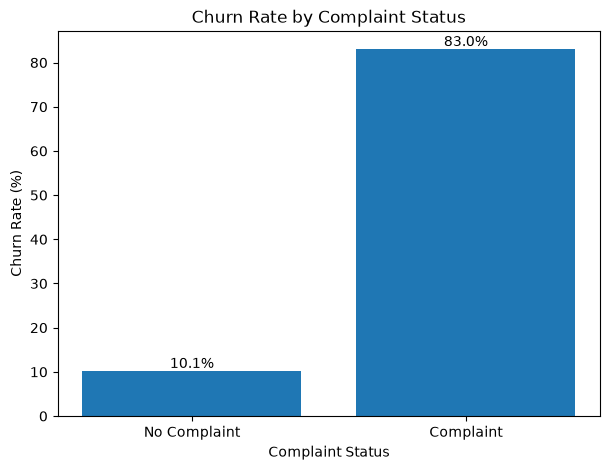

In [6]:
complaint_rates = (
    df.groupby("Complains")["Churn"]
    .mean() * 100
)

plt.figure(figsize=(7, 5))

bars = plt.bar(
    ["No Complaint", "Complaint"],
    complaint_rates.values
)

plt.title("Churn Rate by Complaint Status")
plt.xlabel("Complaint Status")
plt.ylabel("Churn Rate (%)")

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom"
    )

plt.show()

### Business Insight — Customer Complaints

Customers who registered a complaint have an observed churn rate of approximately
83%, compared with only about 10% among customers who did not complain.

This indicates a very strong association between customer complaints and churn.
A complaint may therefore be an important early warning signal for identifying
customers at high risk of leaving.

From a retention perspective, customers who submit complaints could be
prioritized for proactive service recovery, faster issue resolution, and
targeted retention interventions.

However, this analysis shows association rather than causation. Further analysis
and predictive modeling are required to determine how much predictive value
complaint behavior provides when considered alongside other customer features.

# Does subscription length affect churn?

In [7]:
subscription_stats = (
    df.groupby("Churn")["Subscription  Length"]
    .agg(["count", "mean", "median", "min", "max"])
)

subscription_stats.index = ["Retained", "Churned"]

subscription_stats

,count,mean,median,min,max
Retained,2655,32.662524,35.0,3,47
Churned,495,31.894949,35.0,3,45


### The mean difference is only about 0.77, and both groups have the same median of 35. So at first glance, subscription length by itself does not show a strong separation between churners and retained customers.

But averages can hide patterns. For example, churn might be unusually high for very short subscriptions even if the overall means are similar.
visualize the distributions:

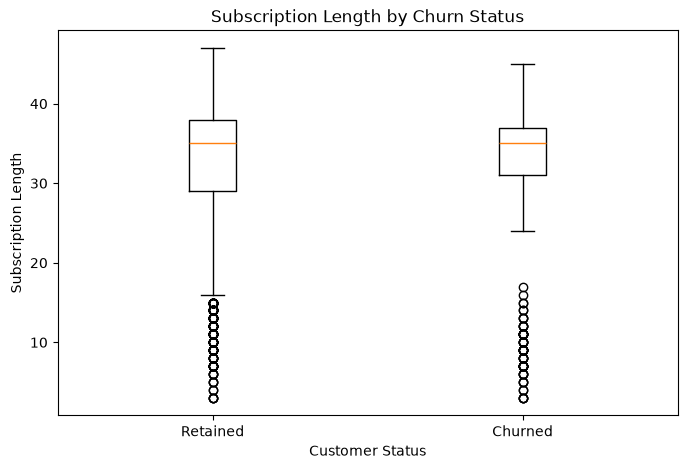

In [8]:
retained_subscription = df.loc[
    df["Churn"] == 0,
    "Subscription  Length"
]

churned_subscription = df.loc[
    df["Churn"] == 1,
    "Subscription  Length"
]

plt.figure(figsize=(8, 5))

plt.boxplot(
    [retained_subscription, churned_subscription],
    tick_labels=["Retained", "Churned"]
)

plt.title("Subscription Length by Churn Status")
plt.xlabel("Customer Status")
plt.ylabel("Subscription Length")

plt.show()

### Business Insight — Subscription Length

Retained customers have an average subscription length of approximately
32.7, compared with 31.9 among churned customers. Both groups have a
median subscription length of 35.

The relatively small difference suggests that subscription length alone
does not clearly distinguish churned customers from retained customers.

However, aggregate statistics may hide churn patterns within particular
subscription-length ranges. Therefore, subscription length should not be
discarded based only on this comparison and can be evaluated further
during predictive modeling and feature analysis.


Complaints
→ very large difference in churn behavior

Subscription length
→ weak separation at the overall group level

# Customer Usage Behavior vs Churn

In [ ]:
#Step 1 — Compare summary statistics
usage_features = [
    "Seconds of Use",
    "Frequency of use",
    "Frequency of SMS"
]

usage_stats = (
    df.groupby("Churn")[usage_features]
    .mean()
    .round(2)
)

usage_stats.index = ["Retained", "Churned"]

usage_stats

,Seconds of Use,Frequency of use,Frequency of SMS
Retained,5014.22,76.98,83.87
Churned,1566.63,29.13,15.80


In [11]:
#Step 2 — Calculate percentage differences:

for feature in usage_features:
    retained_mean = df.loc[df["Churn"] == 0, feature].mean()
    churned_mean = df.loc[df["Churn"] == 1, feature].mean()

    difference_pct = (
        (churned_mean - retained_mean) / retained_mean
    ) * 100

    print(f"{feature}:")
    print(f"  Retained mean: {retained_mean:.2f}")
    print(f"  Churned mean:  {churned_mean:.2f}")
    print(f"  Difference:    {difference_pct:.2f}%")
    print()    

Seconds of Use:
  Retained mean: 5014.22
  Churned mean:  1566.63
  Difference:    -68.76%

Frequency of use:
  Retained mean: 76.98
  Churned mean:  29.13
  Difference:    -62.15%

Frequency of SMS:
  Retained mean: 83.87
  Churned mean:  15.80
  Difference:    -81.16%



### All three point in the same direction: customers who eventually churned were substantially less engaged with the telecom service.
Visualize the strongest patterns

Because these features have very different scales, don't put all three on one axis. Let's create separate plots in one notebook cell:

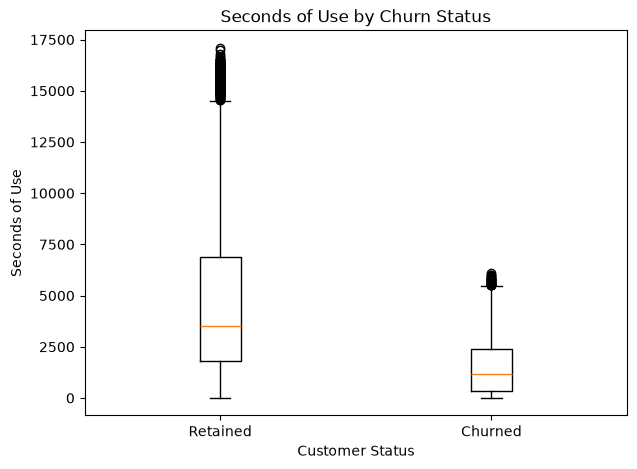

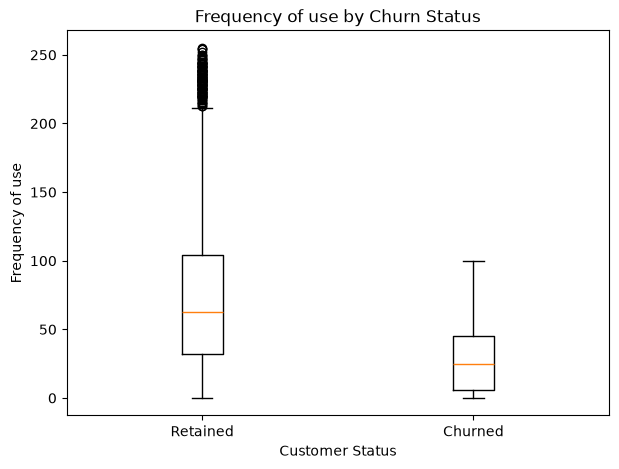

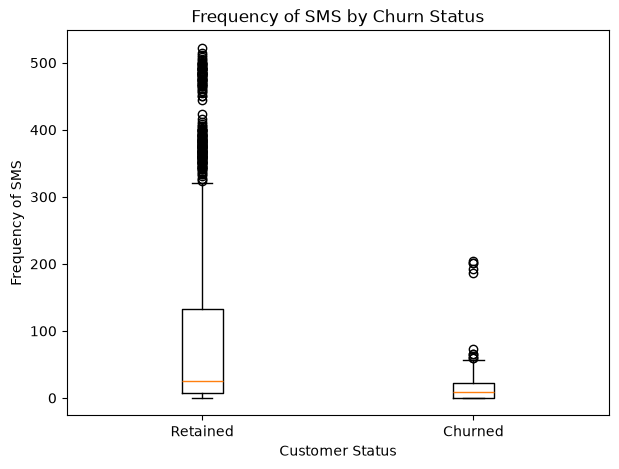

In [12]:
usage_features = [
    "Seconds of Use",
    "Frequency of use",
    "Frequency of SMS"
]

for feature in usage_features:

    retained = df.loc[df["Churn"] == 0, feature]
    churned = df.loc[df["Churn"] == 1, feature]

    plt.figure(figsize=(7, 5))

    plt.boxplot(
        [retained, churned],
        tick_labels=["Retained", "Churned"]
    )

    plt.title(f"{feature} by Churn Status")
    plt.xlabel("Customer Status")
    plt.ylabel(feature)

    plt.show()

### Business Insight — Customer Usage Behavior

Churned customers show substantially lower service engagement than retained
customers across all three usage measures.

- Average seconds of use are approximately 68.8% lower among churned customers.
- Frequency of use is approximately 62.2% lower.
- Frequency of SMS is approximately 81.2% lower.

This suggests that declining or low customer engagement may be an important
indicator of churn risk.

From a retention perspective, customers exhibiting unusually low usage could
be identified for proactive engagement campaigns, personalized offers, or
service recommendations before they leave.

These relationships are associations observed in the dataset and should be
evaluated alongside other customer characteristics during predictive modeling.

# Customer value : Are the customers who churn financially valuable customers?

In [13]:
customer_value_stats = (
    df.groupby("Churn")["Customer Value"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

customer_value_stats.index = ["Retained", "Churned"]

customer_value_stats

,count,mean,median,min,max
Retained,2655,535.51,268.07,0.0,2165.28
Churned,495,124.81,96.84,0.0,987.26


# 1. Customer Value vs Churn:

In [14]:
customer_value_stats = (
    df.groupby("Churn")["Customer Value"]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)

customer_value_stats.index = ["Retained", "Churned"]
customer_value_stats

,mean,median,min,max
Retained,535.51,268.07,0.0,2165.28
Churned,124.81,96.84,0.0,987.26


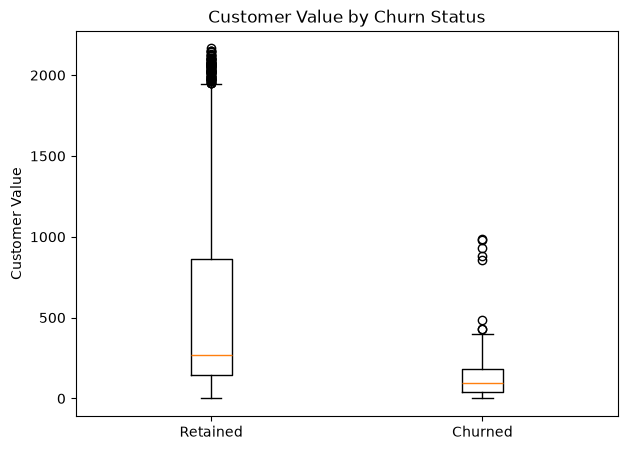

In [15]:
plt.figure(figsize=(7, 5))

plt.boxplot(
    [
        df.loc[df["Churn"] == 0, "Customer Value"],
        df.loc[df["Churn"] == 1, "Customer Value"]
    ],
    tick_labels=["Retained", "Churned"]
)

plt.title("Customer Value by Churn Status")
plt.ylabel("Customer Value")
plt.show()

# 2. Churn by Age Group:

In [16]:
age_churn = (
    df.groupby("Age Group")["Churn"]
    .agg(["count", "mean"])
)

age_churn["churn_rate_pct"] = age_churn["mean"] * 100
age_churn

,count,mean,churn_rate_pct
Age Group,,,
1,123,0.000000,0.000000
2,1037,0.177435,17.743491
3,1425,0.161404,16.140351
4,395,0.200000,20.000000
5,170,0.011765,1.176471


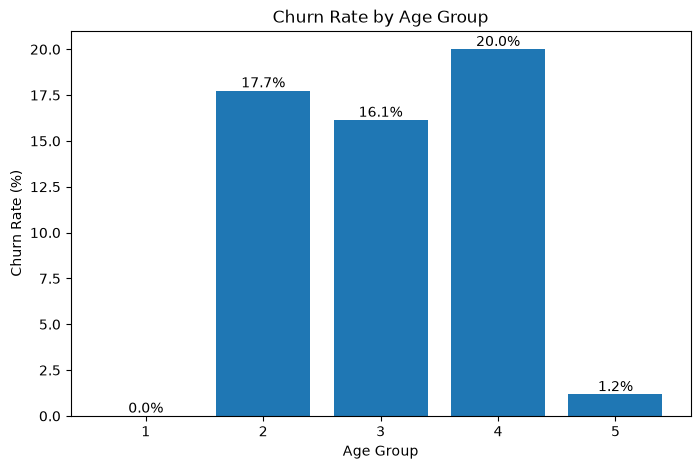

In [17]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    age_churn.index.astype(str),
    age_churn["churn_rate_pct"]
)

plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom"
    )

plt.show()

# 3. Churn by Tariff Plan and Status:


Churn Rate by Tariff Plan
Tariff Plan
1    16.83
2     2.45
Name: Churn, dtype: float64


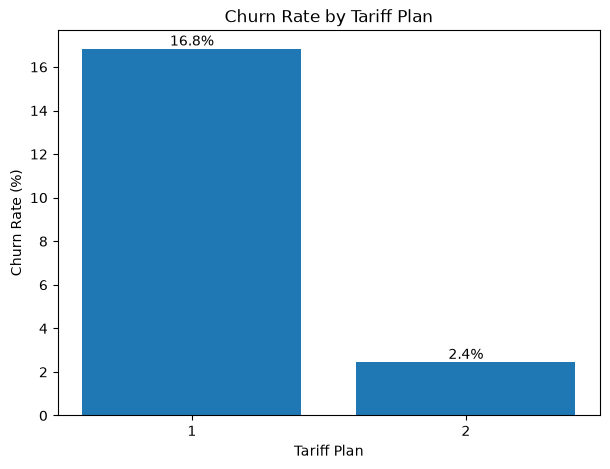


Churn Rate by Status
Status
1     5.28
2    47.31
Name: Churn, dtype: float64


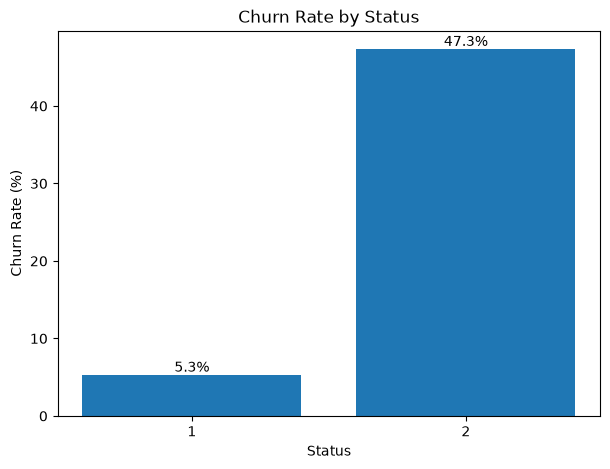

In [18]:
for feature in ["Tariff Plan", "Status"]:

    rates = (
        df.groupby(feature)["Churn"]
        .mean() * 100
    )

    print(f"\nChurn Rate by {feature}")
    print(rates.round(2))

    plt.figure(figsize=(7, 5))

    bars = plt.bar(
        rates.index.astype(str),
        rates.values
    )

    plt.title(f"Churn Rate by {feature}")
    plt.xlabel(feature)
    plt.ylabel("Churn Rate (%)")

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.1f}%",
            ha="center",
            va="bottom"
        )

    plt.show()

# 4. Call Failures vs Churn:

In [19]:
call_failure_stats = (
    df.groupby("Churn")["Call  Failure"]
    .agg(["mean", "median"])
    .round(2)
)

call_failure_stats.index = ["Retained", "Churned"]
call_failure_stats

,mean,median
Retained,7.66,6.0
Churned,7.48,5.0


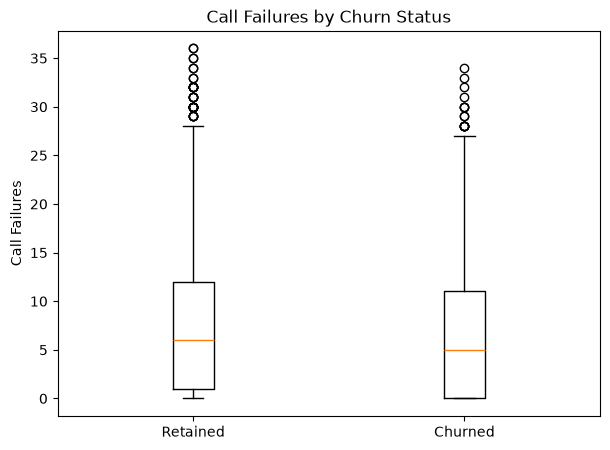

In [20]:
plt.figure(figsize=(7, 5))

plt.boxplot(
    [
        df.loc[df["Churn"] == 0, "Call  Failure"],
        df.loc[df["Churn"] == 1, "Call  Failure"]
    ],
    tick_labels=["Retained", "Churned"]
)

plt.title("Call Failures by Churn Status")
plt.ylabel("Call Failures")
plt.show()

# 5. Correlation analysis:

In [21]:
correlation_matrix = df.corr(numeric_only=True)

churn_correlations = (
    correlation_matrix["Churn"]
    .drop("Churn")
    .sort_values()
)

churn_correlations

Frequency of use          -0.303337
Seconds of Use            -0.298935
Customer Value            -0.289144
Distinct Called Numbers   -0.278867
Frequency of SMS          -0.220754
Charge  Amount            -0.202305
Tariff Plan               -0.105853
Subscription  Length      -0.032588
Age                       -0.017705
Age Group                 -0.014550
Call  Failure             -0.008987
Status                     0.498976
Complains                  0.532053
Name: Churn, dtype: float64

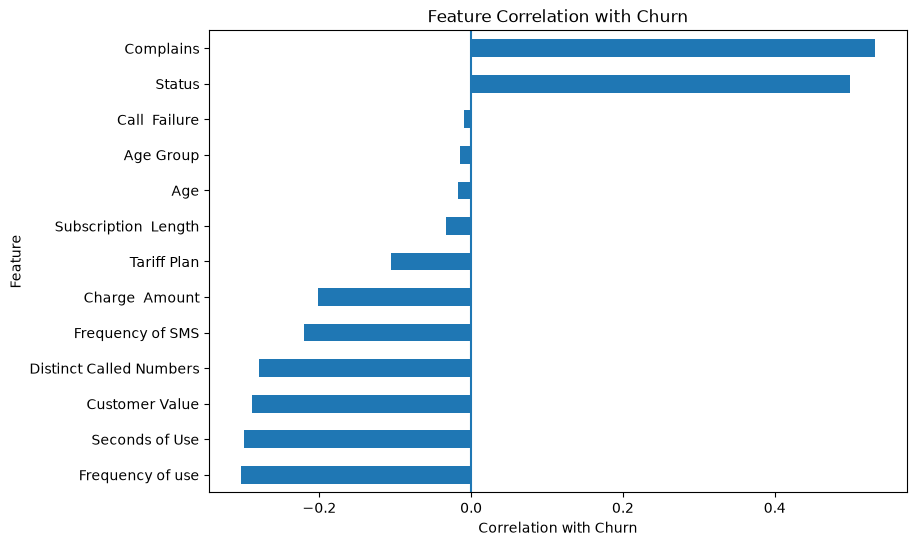

In [22]:
plt.figure(figsize=(9, 6))

churn_correlations.plot(kind="barh")

plt.title("Feature Correlation with Churn")
plt.xlabel("Correlation with Churn")
plt.ylabel("Feature")

plt.axvline(0)
plt.show()

# 6. Finish the notebook with an EDA summary:

## EDA Summary and Business Findings:
- Overall customer churn is approximately 15.7%, creating a moderately
  imbalanced classification problem.

- Customer complaints show a particularly strong association with churn:
  approximately 83% churn among customers who complained versus about
  10% among customers who did not.

- Churned customers exhibit substantially lower service engagement.
  Compared with retained customers, churners have approximately 68.8%
  lower seconds of use, 62.2% lower frequency of use, and 81.2% lower
  SMS frequency.

- Subscription length shows relatively little separation between retained
  and churned customers at the aggregate level.

- These findings suggest that customer dissatisfaction and declining
  engagement may provide useful churn-risk signals.

- Relationships observed during EDA represent associations rather than
  causal effects and will be evaluated further during predictive modeling.